# Supervised Machine Learning: Regression



Regression searches for relationships among variables. For example, you can observe several employees of some company and try to understand how their  salaries depend on their features, such as experience, education level, role, city of employment, and so on.


Regression is used in many different fields, including economics, computer science, and the social sciences. Its importance rises every day with the availability of large amounts of data and increased awareness of the practical value of data.


In situtations where we want to predict continuous values, such as temperature, housing prices, or salary, we can use regression models.



Linear regression is probably one of the most important and widely used regression techniques. It’s among the simplest regression methods. One of its main advantages is the ease of interpreting results.


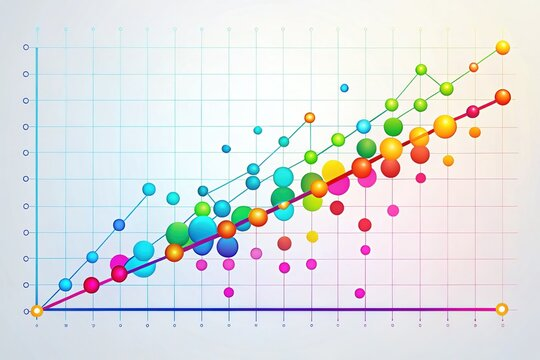

## Linear Regression

Linear regression has been around since the 1800s but it is still used today. It is an easy-to-use and interpret method that generally works for many datasets as long as we have relationshis between our features and target that are somewhat linear and a few other assumptions are met.

To fit q simple 1-D linear model, we use the the equation:
 **y** = m**x** + **b**

 * m is the coefficient of the input feature.

 * b is the value at which the line intersects the y-axis,  i.e. the y - intercept.

 * x is the input or predictor, generally refered to as the independent variable

 * y is the output or target (i.e. the dependent variable)



 *   We can generalize this to multidimensional data (with n features):


 y = m1 X1 + m2X2 + m3X3 + ....+ mn Xn



 * We can use the sklearn and statsmodels libraries to model the linear regression.


**Multicollinearity**

Collinearity means two predictors in your model carry (almost) the same information—one can be predicted from the other. When that happens, the model struggles to tell which one really drives the outcome, so their coefficients become unstable and standard errors get big.
Example: including height in cm and inches at the same time.


Multicollinearity happens when one predictor can be explained well by a combination of other predictors. It doesn’t “break” OLS, but it inflates coefficient standard errors, making:

- large SEs and small t-stats,

- unstable/sign-flipping coefficients when you add/remove variables,

- high model R² but few individually significant predictors.

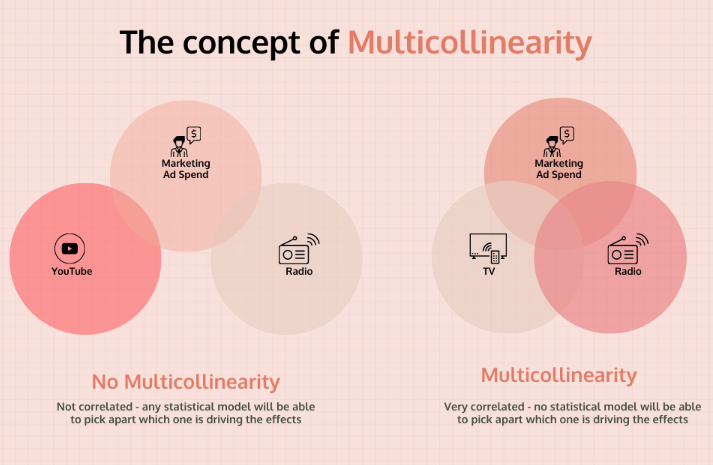

**Collinearity/multicollinearity** is not “good” for linear regression.

**Why it’s a problem**


* Perfect collinearity (one feature is an exact linear combo of others): OLS can’t compute unique coefficients (matrix is singular).

* Near multicollinearity: Coefficients become unstable, standard errors inflate, p-values look weak, and signs/sizes can flip with tiny data/model changes.

* Interpretation suffers: You can’t confidently say which feature “drives” the outcome.

* Prediction caveat: In-sample RMSE may look fine, but extrapolation is risky and coefficient instability is high.


**How to identify**
* VIF (Variance Inflation Factor): measures how much a feature is explained by the others.
Rule of thumb: VIF > 5 (watch), > 10 (serious).

* Condition number / singular values: large values (often > 30) suggest strong multicollinearity.

* Large Std error

**What to do?**

* Drop or merge redundant features; use domain logic.

* Center polynomial/interaction terms; consider orthogonal polynomials.

* Use Ridge/Lasso/Elastic Net or PCA before regression.

* Collect more data if feasible.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
from google.colab import files


In [ ]:
#upload the file #
uploaded=files.upload()

Saving housing_data_sample.csv to housing_data_sample.csv


In [ ]:
df = pd.read_csv('housing_data_sample.csv', index_col='Id')
df.head()

,LotArea,YearBuilt,FullBath,TotRmsAbvGrd,GarageArea,1stFlrSF,2ndFlrSF,SalePrice
Id,,,,,,,,
1,8450,2003,2,8,548,856,854,208500
2,9600,1976,2,6,460,1262,0,181500
3,11250,2001,2,6,608,920,866,223500
4,9550,1915,1,7,642,961,756,140000
5,14260,2000,2,9,836,1145,1053,250000


In [ ]:
# Correlation between the target and the other features
df.corr()['SalePrice']


,SalePrice
LotArea,0.263843
YearBuilt,0.522897
FullBath,0.560664
TotRmsAbvGrd,0.533723
GarageArea,0.623431
1stFlrSF,0.605852
2ndFlrSF,0.319334
SalePrice,1.000000


### Sklearn Linear Regression

In [ ]:
#Let us break or divide the data into train and tests sets  using the sklearn library
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop('SalePrice', axis=1), df['SalePrice'], random_state=42)
# In train_test_split, if you don’t specify test_size or train_size, the default is test_size=0.25, so you get 25% test and 75% train. random_state=42 just fixes the shuffling, not the split fraction.


In [ ]:
# fit a linear regression model from sklearn to the data

from sklearn.linear_model import LinearRegression

linregs = LinearRegression()
linregs.fit(x_train, y_train)
print(linregs.score(x_train, y_train))
print(linregs.score(x_test, y_test))


0.6922037863468924
0.7335111149578265


R2 , coefficient of determination is the built-in score method. The coefficient of determination is 1.0 when we have a perfect model.

In [ ]:
# The coefficients of the model
linregs.coef_

array([ 4.69748692e-01,  8.27939635e+02, -3.57322963e+03, -2.59678130e+01,
        6.46264545e+01,  9.74383176e+01,  7.18384417e+01])

In [ ]:
# The intercept of the model
linregs.intercept_

np.float64(-1619889.0110532867)

<Axes: ylabel='None'>

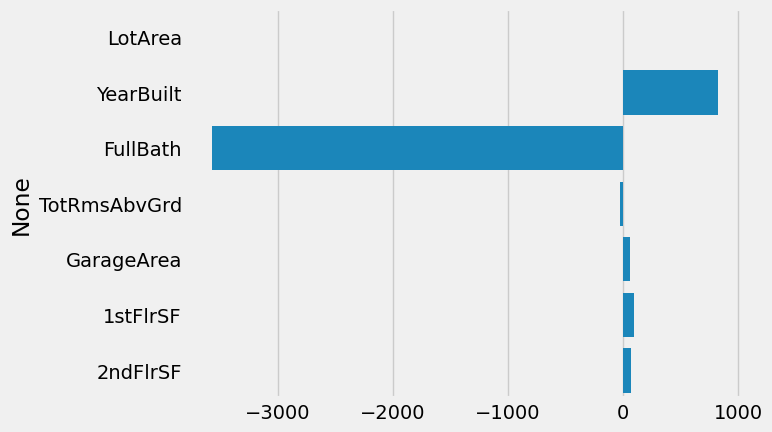

In [ ]:
sns.barplot(x=linregs.coef_, y=x_train.columns)

Train R^2: 0.6922 | Test R^2: 0.7335
Train MSE: 1868767822.614477 | Test MSE: 1866836998.733751


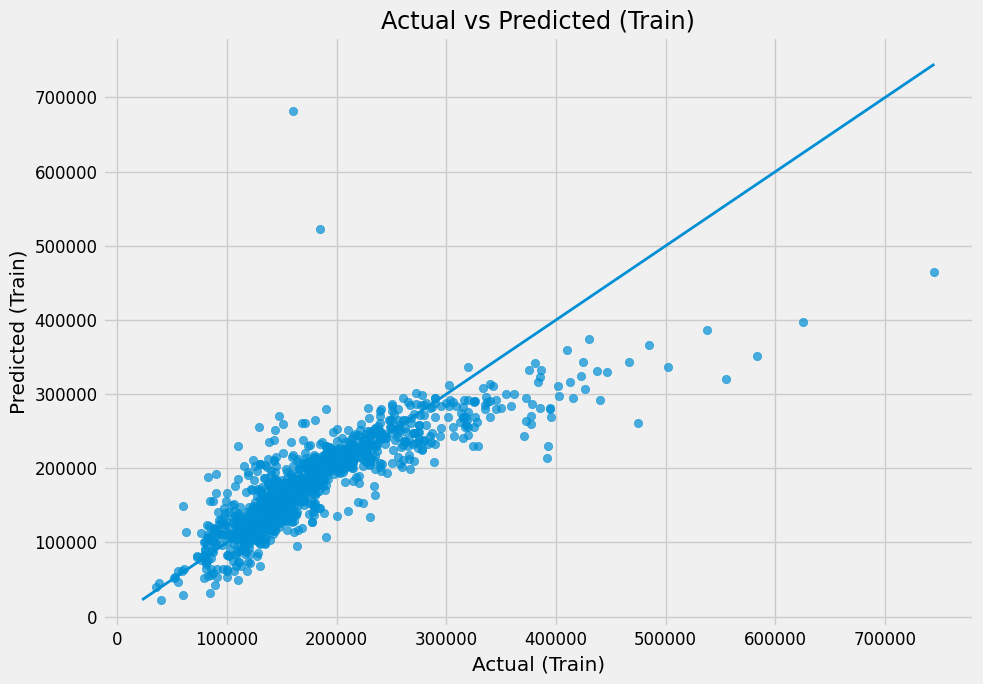

In [ ]:
# Fit LinearRegression, report metrics, and visualize (no MSE plot)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Bigger plots
plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["font.size"] = 12

def _as_2d(a):
    a = np.asarray(a)
    return a.reshape(-1, 1) if a.ndim == 1 else a

Xtr, ytr = _as_2d(x_train), np.asarray(y_train)
Xte, yte = _as_2d(x_test),  np.asarray(y_test)

# Train
linregs = LinearRegression()
linregs.fit(Xtr, ytr)

# Predict
ytr_pred = linregs.predict(Xtr)
yte_pred = linregs.predict(Xte)

# Metrics (printed only)
r2_train = r2_score(ytr, ytr_pred)
r2_test  = r2_score(yte, yte_pred)
mse_train = mean_squared_error(ytr, ytr_pred)
mse_test  = mean_squared_error(yte, yte_pred)

print(f"Train R^2: {r2_train:.4f} | Test R^2: {r2_test:.4f}")
print(f"Train MSE: {mse_train:.6f} | Test MSE: {mse_test:.6f}")

# --- Visualization: Model view (no MSE bar chart) ---
if Xtr.shape[1] == 1:
    x1 = Xtr[:, 0]
    order = np.argsort(x1)
    x_line = x1[order].reshape(-1, 1)
    y_line = linregs.predict(x_line)

    plt.figure(figsize=(10, 7))
    plt.scatter(x1, ytr, alpha=0.7)
    plt.plot(x_line[:, 0], y_line, linewidth=2)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Linear Regression: Train Data & Fitted Line")
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(10, 7))
    plt.scatter(ytr, ytr_pred, alpha=0.7)
    lims = [min(np.min(ytr), np.min(ytr_pred)),
            max(np.max(ytr), np.max(ytr_pred))]
    plt.plot(lims, lims, linewidth=2)
    plt.xlabel("Actual (Train)")
    plt.ylabel("Predicted (Train)")
    plt.title("Actual vs Predicted (Train)")
    plt.tight_layout()
    plt.show()


### Linear Regression Using Statmodels

In [ ]:
import statsmodels.api as sm

In [ ]:
x1 = sm.add_constant(x_train)
sm_lin_reg= sm.OLS(y_train, x1)
res = sm_lin_reg.fit()


print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.690
Method:                 Least Squares   F-statistic:                     349.2
Date:                Sat, 04 Oct 2025   Prob (F-statistic):          6.20e-273
Time:                        09:31:00   Log-Likelihood:                -13242.
No. Observations:                1095   AIC:                         2.650e+04
Df Residuals:                    1087   BIC:                         2.654e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -1.62e+06   1.07e+05    -15.165   

### Regularized linear regression

#### LassoCV

LassoCV is a linear regression model that adds an L1 penalty to the coefficients and automatically chooses how strong that penalty should be using cross-validation. The penalty shrinks coefficients toward zero, and some become exactly zero, so the model effectively selects features while fitting. It’s useful when you have many or correlated predictors and want a simpler, more stable model. Scale your features first, then fit; afterwards you can read the chosen penalty in alpha_ and the fitted weights in coef_.

In [ ]:
from sklearn.linear_model import LassoCV

l1_linreg = LassoCV()
l1_linreg.fit(x_train, y_train)

LassoCV()

In [ ]:
l1_linreg.alpha_
# l1_linreg.alpha_ is the regularization strength (α) chosen by the model after fitting, typically when you used a cross-validated estimator like LassoCV, ElasticNetCV, or RidgeCV.
# In scikit-learn, a trailing underscore (_) means “learned from data after .fit().”
# So alpha_ is the best α found by CV (larger α ⇒ stronger shrinkage; with L1/Lasso it pushes more coefficients exactly to 0).

np.float64(228888.65931632454)

In [ ]:
# Coefficients
l1_linreg.coef_

array([4.27009150e-01, 5.07702347e+02, 0.00000000e+00, 0.00000000e+00,
       8.02080376e+01, 9.60455704e+01, 6.70594638e+01])

In [ ]:
l1_linreg.score(x_test, y_test)

0.730783035952028

#### RidgeCV

RidgeCV is linear regression with an L2 penalty on the coefficients, and it automatically picks the penalty strength (alpha) by cross-validation. The L2 penalty shrinks coefficients toward zero but rarely makes them exactly zero, so it doesn’t do feature selection; instead it stabilizes estimates when predictors are many or highly correlated, reducing variance and taming multicollinearity. Scale your features first, fit the model, then read the chosen penalty in alpha_ and the fitted weights in coef_.

In [ ]:
from sklearn.linear_model import RidgeCV

l2_linreg = RidgeCV()
l2_linreg.fit(x_train, y_train)
l2_linreg.coef_

array([ 4.69961952e-01,  8.26351818e+02, -3.35200764e+03, -4.04117423e+01,
        6.46405519e+01,  9.73549918e+01,  7.17380074e+01])

In [ ]:
l2_linreg.score(x_test,y_test)

0.7335592514270202

In [ ]:
l2_linreg.score(x_train,y_train)

0.6922026698385533

#### ElasticNetCV



ElasticNetCV is linear regression that uses a mix of L1 (lasso) and L2 (ridge) penalties and automatically chooses how strong the penalty should be (alpha) and how to mix L1 vs L2 (l1_ratio) by cross-validation. It can both stabilize coefficients when features are correlated and set some to zero for feature selection. Scale features first; after fitting you can read alpha_, l1_ratio_, and coef_.

In [ ]:
from sklearn.linear_model import ElasticNetCV

en_linreg = ElasticNetCV()
en_linreg.fit(x_train, y_train)
en_linreg.coef_


array([ 1.28287688,  3.46879826,  0.        ,  0.        , 27.15263788,
       41.1722103 , 27.02242165])

In [ ]:
en_linreg.alpha_

np.float64(457777.3186326491)

In [ ]:
en_linreg.score(x_test, y_test)


0.40002308131932474

So to choose the best model to use between the three, we can evaluate their performance on the test data. We will not use L2 regularization because it contained large negative  values for variables we kow should be positive coefficients. The R2 values from Lasso and ElasticNetCV models are about 0.73 and 0.4. It is clear the Lasso model is much better, so we can use that as our best linear regression model so far.

In [ ]:
# Mean Squared Error MSE
from sklearn.metrics import mean_squared_error as mse

mse(y_test, l1_linreg.predict(x_test))

1885948035.2885683

In [ ]:
# Root Mean Square RMSE

#rmse = mse(y_test, l1_linreg.predict(x_test), squared=False)
#print(f"RMSE: {rmse:.4f}")


y_pred = l1_linreg.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 43427.5032


In [ ]:
# Mean Absolute Error
from sklearn.metrics import mean_absolute_error as mae

mae(y_test, l1_linreg.predict(x_test))

27295.84646037545

## Regression with KNN

K-Nearest Neighbors (KNN) predicts by looking at the k closest points in feature space, assuming similar points lie near each other. For classification it takes a majority vote; for regression it averages their values. Example: for point X, check its 5 nearest neighbors to decide X’s label or value.

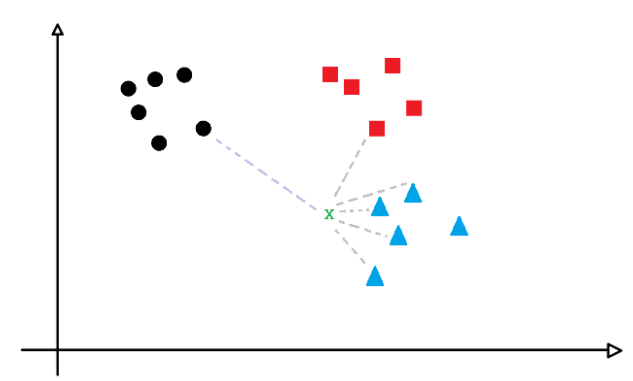

Notice that 4 of those nearest points are triangles and just one is a square. The circles "cluster" is way too far to be considered. So, we can conclude that the X point is a triangle, according to KNN logic.


KNN regression predicts a number by averaging the targets of the k nearest neighbors. In scikit-learn, KNeighborsRegressor(n_neighbors=k) finds the k closest points and returns the mean of their y-values.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()
knr.fit(x_train, y_train)
print(knr.score(x_train, y_train))
print(knr.score(x_test, y_test))

0.7169386324727904
0.6053929038884596


In [ ]:
# Mean Squared Error MSE
from sklearn.metrics import mean_squared_error as mse

mse(y_test, knr.predict(x_test))

2764344662.507507

In [ ]:
# Root Mean Square RMSE

#rmse = mse(y_test, l1_linreg.predict(x_test), squared=False)
#print(f"RMSE: {rmse:.4f}")


y_pred = knr.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 52577.0355


In [ ]:
# Mean Absolute Error
from sklearn.metrics import mean_absolute_error as mae

mae(y_test, knr.predict(x_test))

31580.23287671233